**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

**Loading Dataset**

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print("Shape:", df.shape)
print(df['Class'].value_counts())

Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


**Preproscessing**

In [ ]:
df['Class'] = df['Class'].astype(int)
df = df.drop(columns=['Time'])

X = df.drop(columns=['Class'])
y = df['Class'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Split the Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train_ae = X_train[y_train == 0]                       # For training, use only non-fraud samples

In [ ]:
print("Training shape:", X_train_ae.shape)
print("Test shape:", X_test.shape)

Training shape: (227451, 29)
Test shape: (56962, 29)


**Building Dense Autoencoders**

In [ ]:
input_dim = X_train_ae.shape[1]
encoding_dim = 14

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)


decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,939 (34.92 KB)

 Trainable params: 8,939 (34.92 KB)

 Non-trainable params: 0 (0.00 B)

**Train**

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[es],
    verbose=2
)

Epoch 1/100
800/800 - 6s - 7ms/step - loss: 0.2421 - val_loss: 0.1681
Epoch 2/100
800/800 - 7s - 9ms/step - loss: 0.1480 - val_loss: 0.1235
Epoch 3/100
800/800 - 3s - 4ms/step - loss: 0.1228 - val_loss: 0.1086
Epoch 4/100
800/800 - 7s - 9ms/step - loss: 0.1068 - val_loss: 0.0955
Epoch 5/100
800/800 - 9s - 11ms/step - loss: 0.0976 - val_loss: 0.0880
Epoch 6/100
800/800 - 5s - 6ms/step - loss: 0.0922 - val_loss: 0.0807
Epoch 7/100
800/800 - 3s - 4ms/step - loss: 0.0860 - val_loss: 0.0760
Epoch 8/100
800/800 - 3s - 4ms/step - loss: 0.0801 - val_loss: 0.0761
Epoch 9/100
800/800 - 3s - 3ms/step - loss: 0.0764 - val_loss: 0.0710
Epoch 10/100
800/800 - 7s - 9ms/step - loss: 0.0716 - val_loss: 0.0667
Epoch 11/100
800/800 - 5s - 6ms/step - loss: 0.0695 - val_loss: 0.0647
Epoch 12/100
800/800 - 5s - 7ms/step - loss: 0.0663 - val_loss: 0.0634
Epoch 13/100
800/800 - 9s - 12ms/step - loss: 0.0639 - val_loss: 0.0634
Epoch 14/100
800/800 - 4s - 5ms/step - loss: 0.0614 - val_loss: 0.0587
Epoch 15/100


**Plot Training Loss**

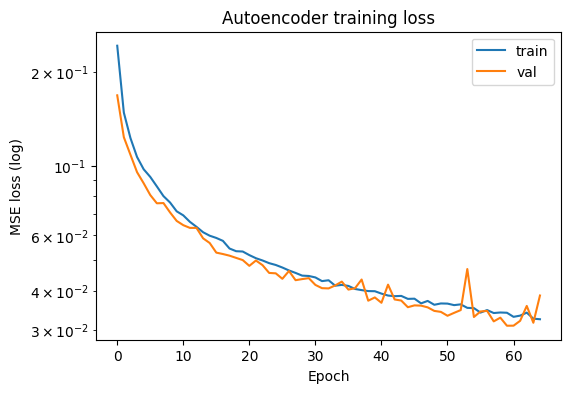

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (log)')
plt.legend()
plt.title('Autoencoder training loss')
plt.show()

**Compute reonstruction error on test data**

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


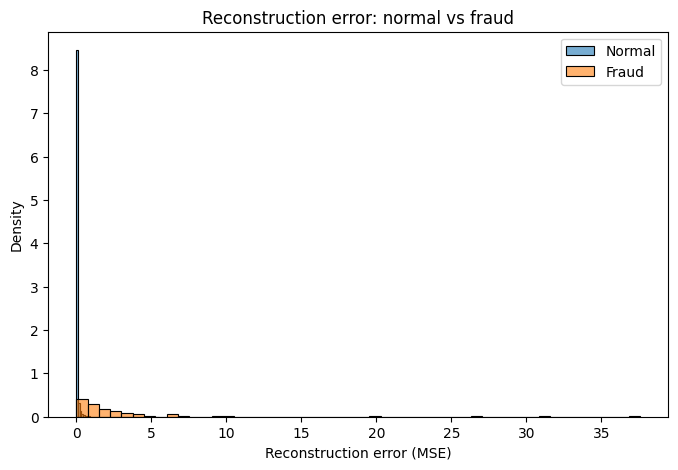

In [ ]:
X_test_pred = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

results = pd.DataFrame()
results['mse'] = mse
results['Class'] = y_test

plt.figure(figsize=(8,5))
sns.histplot(results[results['Class']==0]['mse'], label='Normal', bins=50, stat='density', color='C0', alpha=0.6)
sns.histplot(results[results['Class']==1]['mse'], label='Fraud', bins=50, stat='density', color='C1', alpha=0.6)
plt.legend()
plt.xlabel('Reconstruction error (MSE)')
plt.title('Reconstruction error: normal vs fraud')
plt.show()

**Choose threshold and evaluate**

In [ ]:
X_train_pred = autoencoder.predict(X_train_ae)
mse_train = np.mean(np.power(X_train_ae - X_train_pred, 2), axis=1)
thr = np.mean(mse_train) + 3*np.std(mse_train)
print("Threshold (mean+3std) = ", thr)

precision, recall, pr_thresholds = precision_recall_curve(results['Class'], results['mse'])
f1_scores = 2*precision*recall/(precision+recall+1e-10)
best_idx = np.argmax(f1_scores)
best_thr = pr_thresholds[best_idx] if best_idx < len(pr_thresholds) else pr_thresholds[-1]
print("Best F1 threshold (from PR curve):", best_thr, "Best F1:", f1_scores[best_idx])

threshold = best_thr

y_pred = (results['mse'] >= threshold).astype(int)

print("\nConfusion Matrix (threshold = {:.6f}):".format(threshold))
print(confusion_matrix(results['Class'], y_pred))
print("\nClassification Report:")
print(classification_report(results['Class'], y_pred, digits=4))

roc_auc = roc_auc_score(results['Class'], results['mse'])
print("ROC AUC:", roc_auc)

pr_auc = auc(recall, precision)
print("PR AUC:", pr_auc)

7108/7108 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Threshold (mean+3std) =  0.3093688712063818
Best F1 threshold (from PR curve): 1.2556167891432537 Best F1: 0.5333333332833347

Confusion Matrix (threshold = 1.255617):
[[56819    45]
 [   46    52]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.9992    0.9992     56864
           1     0.5361    0.5306    0.5333        98

    accuracy                         0.9984     56962
   macro avg     0.7676    0.7649    0.7663     56962
weighted avg     0.9984    0.9984    0.9984     56962

ROC AUC: 0.9604886130028827
PR AUC: 0.5121953315790123


**Examples**

In [ ]:
top_fraud = results[results['Class']==1].sort_values('mse', ascending=False).head(5)
print("Top fraud reconstruction errors:\n", top_fraud)

Top fraud reconstruction errors:
              mse  Class
19638  37.578256      1
9730   30.931000      1
1146   26.655319      1
31804  26.655319      1
7299   19.772758      1
